In [183]:
import numpy as np
import re
import matplotlib.pyplot as plt

# Initial preprocessing of parsed data

In [184]:
import pandas as pd
from sqlalchemy import create_engine

DB = {
    "db": "hse_parsing",
    "user": "user",
    "password": "Q7vX9pL2mK8zT4rWc5Yh",
    "host": "147.78.64.204",
    "port": "5432"
}

engine = create_engine(
    f"postgresql+psycopg2://{DB['user']}:{DB['password']}@{DB['host']}:{DB['port']}/{DB['db']}"
)

In [185]:
df_events = pd.read_sql("SELECT * FROM events", engine)
df_specs = pd.read_sql("SELECT * FROM event_specs", engine)
df_history = pd.read_sql("SELECT * FROM event_history", engine)
df_ohlc = pd.read_sql("SELECT * FROM currency_ohlc", engine)

In [186]:
df_events

,id,event_id,datetime,currency,currency_full,impact,title,actual,forecast,previous
0,1,148004,2026-03-23 16:00:00,USD,United States dollar,Low Impact Expected,Construction Spending m/m,None,0.1%,0.3%
1,2,150602,2026-03-23 17:00:00,EUR,Euro,Low Impact Expected,Consumer Confidence,None,-15,-12
2,3,152747,2026-03-23 22:00:00,NZD,New Zealand dollar,Medium Impact Expected,RBNZ Gov Breman Speaks,None,None,None
3,4,150901,2026-03-24 00:00:00,AUD,Australian dollar,Low Impact Expected,Flash Manufacturing PMI,None,None,51.0
4,5,150902,2026-03-24 00:00:00,AUD,Australian dollar,Low Impact Expected,Flash Services PMI,None,None,52.8
...,...,...,...,...,...,...,...,...,...,...
9853,10006,135982,2024-04-05 00:00:00,USD,United States dollar,High Impact Expected,Unemployment Rate,3.8%,3.9%,3.9%
9854,10007,140118,2024-04-05 08:15:00,USD,United States dollar,Low Impact Expected,FOMC Member Barkin Speaks,None,None,None
9855,10008,137036,2024-04-05 09:00:00,CAD,Canadian dollar,Medium Impact Expected,Ivey PMI,57.5,54.2,53.9
9856,10009,140125,2024-04-05 11:30:00,USD,United States dollar,Low Impact Expected,FOMC Member Bowman Speaks,None,None,None


In [187]:
# dates
df_events["datetime"] = pd.to_datetime(df_events["datetime"])
df_events["event_date"] = df_events["datetime"].dt.date
df_history["date"] = pd.to_datetime(df_history["date"])
df_ohlc["bar_date"] = pd.to_datetime(df_ohlc["bar_date"])


# text columns
df_events["currency"] = df_events["currency"].astype(str).str.upper().str.strip()
df_events["impact"] = df_events["impact"].astype(str).str.strip()
df_events["title"] = df_events["title"].astype(str).str.strip()


# impact to number
def impact_to_num(x):
    s = str(x).lower()
    if "high" in s:
        return 3
    elif "medium" in s:
        return 2
    elif "low" in s:
        return 1
    elif "non" in s:
        return 0
    else:
        return np.nan

df_events["impact_level"] = df_events["impact"].apply(impact_to_num)

# saving raw values
for col in ["actual", "forecast", "previous"]:
    df_events[f"{col}_raw"] = df_events[col]
    df_history[f"{col}_raw"] = df_history[col]

# normalizing values
def parse_value(x):
    if pd.isna(x):
        return np.nan

    s = str(x).strip()

    if s == "" or s.upper() in ["NULL", "NONE", "NaN"]:
        return np.nan

    s = s.replace(",", "")
    s = s.replace("−", "-")

    multiplier = 1.0
    is_percent = False

    if s.endswith("%"):
        is_percent = True
        s = s[:-1].strip()
    if s.endswith(("K", "k")):
        multiplier = 1000
        s = s[:-1].strip()
    elif s.endswith(("M", "m")):
        multiplier = 1000000
        s = s[:-1].strip()
    elif s.endswith(("B", "b")):
        multiplier = 1000000000
        s = s[:-1].strip()

    mask = re.search(r"-?\d+(\.\d+)?", s)
    if not mask:
        return np.nan
# https://www.w3schools.com/python/python_try_except.asp
    try:
        num = float(mask.group(0)) * multiplier
        if is_percent:
            num = num / 100

        return num
    except:
        return np.nan


for col in ["actual", "forecast", "previous"]:
    df_events[f"{col}_num"] = df_events[col].apply(parse_value)
    df_history[f"{col}_num"] = df_history[col].apply(parse_value)


# flags
df_events["has_actual"] = df_events["actual_num"].notna()
df_events["has_forecast"] = df_events["forecast_num"].notna()
df_events["has_previous"] = df_events["previous_num"].notna()

df_events["is_quantitative"] = (
    df_events["has_actual"] |
    df_events["has_forecast"] |
    df_events["has_previous"]
)


# checking for speech
speech_keywords = [
    "speaks", "speech", "statement", "remarks",
    "testifies", "press conference", "conference",
    "forum", "panel"
]

def is_speech(row):
    title = str(row["title"]).lower()
    keyword_flag = any(k in title for k in speech_keywords)
    no_numbers = (
        pd.isna(row["actual_num"]) and
        pd.isna(row["forecast_num"]) and
        pd.isna(row["previous_num"])
    )

    return keyword_flag or no_numbers

df_events["is_speech_like"] = df_events.apply(is_speech, axis=1)


# OHLC to num
for col in ["open", "high", "low", "close"]:
    df_ohlc[col] = pd.to_numeric(df_ohlc[col], errors="coerce")

In [188]:
print(df_events[["actual_raw", "actual_num"]].tail(20))
print(df_events["impact_level"].value_counts(dropna=False))
print(df_events["is_speech_like"].value_counts())

     actual_raw    actual_num
9838       None           NaN
9839     111.8%  1.118000e+00
9840       0.2%  2.000000e-03
9841      -0.2% -2.000000e-03
9842      -1.0% -1.000000e-02
9843       0.2%  2.000000e-03
9844       715B  7.150000e+11
9845        -38 -3.800000e+01
9846       50.2  5.020000e+01
9847     -25.1B -2.510000e+10
9848      -0.5% -5.000000e-03
9849      -2.2K -2.200000e+03
9850       6.1%  6.100000e-02
9851       0.3%  3.000000e-03
9852       303K  3.030000e+05
9853       3.8%  3.800000e-02
9854       None           NaN
9855       57.5  5.750000e+01
9856       None           NaN
9857      14.1B  1.410000e+10
impact_level
1    6610
3    1746
2    1237
0     265
Name: count, dtype: int64
is_speech_like
False    7332
True     2526
Name: count, dtype: int64


## event_specs table preprocessing

In [189]:
df_specs = df_specs.copy()

df_specs["label"] = df_specs["label"].astype(str).str.strip()
df_specs["value"] = df_specs["value"].astype(str).str.strip()

df_specs["label"] = df_specs["label"].replace({"": np.nan, "None": np.nan, "NaN": np.nan})
df_specs["value"] = df_specs["value"].replace({"": np.nan, "None": np.nan, "NaN": np.nan})

# normalizing values
def normalize_spec_label(x):
    if pd.isna(x):
        return np.nan
    s = str(x).strip().lower()
    mapping = {
        "usual effect": "usual_effect",
        "measures": "measures",
        "frequency": "frequency",
        "source": "source",
        "why traders care": "why_traders_care",
        "derived via": "derived_via",
        "description": "description",
        "ff notes": "ff_notes",
        "ff notice": "ff_notes",
        "next release": "next_release",
    }

    return mapping.get(s, re.sub(r"[^a-z0-9]+", "_", s).strip("_"))

df_specs["label_norm"] = df_specs["label"].apply(normalize_spec_label)

# pivoting table, taking only first value for ff_notes
specs_wide_df = df_specs.pivot_table(
    index="event_id",
    columns="label_norm",
    values="value",
    aggfunc="first"
).reset_index()

print(df_specs.shape)
print(specs_wide_df.shape)

(76877, 5)
(9849, 13)


## normalizing usual_effect to number

In [190]:
# extracting usual effect
def usual_effect_to_label(text):
    if pd.isna(text):
        return np.nan

    s = str(text).lower()
    if "greater than" in s and "good for currency" in s:
        return "gt_good"
    if "less than" in s and "good for currency" in s:
        return "lt_good"
    if "greater than" in s and "bad for currency" in s:
        return "gt_bad"
    if "less than" in s and "bad for currency" in s:
        return "lt_bad"

    return np.nan

specs_wide_df["effect_rule"] = specs_wide_df["usual_effect"].apply(usual_effect_to_label)

# direction for the currency
def get_signal(rule, actual, forecast):
    if pd.isna(rule) or pd.isna(actual) or pd.isna(forecast):
        return np.nan

    if actual > forecast:
        effect = "gt"
    elif actual < forecast:
        effect = "lt"
    else:
        return 0

    if rule == "gt_good":
        return 1 if effect == "gt" else -1
    if rule == "lt_good":
        return 1 if effect == "lt" else -1
    if rule == "gt_bad":
        return -1 if effect == "gt" else 1
    if rule == "lt_bad":
        return -1 if effect == "lt" else 1

    return np.nan

# specs_wide_df["effect_rule"].value_counts(dropna=False)


## filling actual/forecast data

sorting history table data

In [191]:
df_history_sorted = df_history.copy()
df_history_sorted = df_history_sorted.sort_values(["event_id", "date"])

history_last_df = (
    df_history_sorted
    .groupby("event_id")
    .last()
    .reset_index()
)

history_last_df = history_last_df.drop(columns=["actual", "forecast",	"previous",	"actual_raw",	"forecast_raw",	"previous_raw"])
history_last_df

,event_id,id,date,actual_num,forecast_num,previous_num
0,1,1,2026-03-23,-2.000000e-03,1.000000e-03,3.000000e-03
1,2,7,2026-03-23,-1.200000e+01,-1.500000e+01,-1.200000e+01
2,6,13,2026-03-24,2.000000e-02,1.700000e-02,2.000000e-02
3,8,19,2026-03-24,-5.700000e-02,NaN,-5.700000e-02
4,17,25,2026-03-24,4.590000e+00,NaN,4.590000e+00
...,...,...,...,...,...,...
6578,10004,39962,2024-04-05,3.000000e-03,3.000000e-03,2.000000e-03
6579,10005,39968,2024-04-05,3.030000e+05,2.120000e+05,2.700000e+05
6580,10006,39974,2024-04-05,3.800000e-02,3.900000e-02,3.900000e-02
6581,10008,39980,2024-04-05,5.750000e+01,5.420000e+01,5.390000e+01


merging history data with pivoted event table

In [192]:
# merging events table with specs pivot table
events_enriched_df = df_events.merge(
    specs_wide_df,
    how="left",
    left_on="id",
    right_on="event_id"
)

events_enriched_df = events_enriched_df.drop(columns=["event_id_y"])
events_enriched_df = events_enriched_df.rename(columns={"event_id_x": "event_id"})
events_enriched_df = events_enriched_df.drop(columns=["actual", "forecast",	"previous",	"actual_raw",	"forecast_raw",	"previous_raw"])
# events_enriched_df.info()

# renaming columns to avoid conflicts
history_last_df = history_last_df.rename(columns={
    "actual_num": "actual_num_hist",
    "forecast_num": "forecast_num_hist",
    "previous_num": "previous_num_hist"
})

history_last_df = history_last_df[[
    "event_id",
    "actual_num_hist",
    "forecast_num_hist",
    "previous_num_hist"
]]
# history_last_df


# merging events+specs table with history
events_full_df = events_enriched_df.merge(
    history_last_df,
    how="left",
    left_on="id",
    right_on="event_id"
)

events_full_df = events_full_df.drop(columns=["event_id_y"])
events_full_df = events_full_df.rename(columns={"event_id_x": "event_id"})
# events_full_df.info()

# filling forecast/actuat data
events_full_df["actual_final"] = events_full_df["actual_num"].fillna(events_full_df["actual_num_hist"])
events_full_df["forecast_final"] = events_full_df["forecast_num"].fillna(events_full_df["forecast_num_hist"])
events_full_df["previous_final"] = events_full_df["previous_num"].fillna(events_full_df["previous_num_hist"])
# events_full_df.info()


events_full_df = events_full_df.drop(columns=[
    "currency_full",
    "acro_expand",
    "also_called",
    "derived_via",
    "description",
    "ff_notes",
    "next_release",
    "speaker",
    "why_traders_care",
    "actual_num_hist",
    "forecast_num_hist",
    "previous_num_hist",
    "actual_num",
    "forecast_num",
    "previous_num"
])

# events_full_df.info()

# creating final pre merge events table
df_events_final = events_full_df.copy()
df_events_final["event_date"] = pd.to_datetime(df_events_final["event_date"])
df_events_final = df_events_final.drop(columns=["impact","event_id"])
# df_events_final.info()

# creating event classification
def classify_event(text):
    text = str(text).lower()

    if any(i in text for i in ["cpi", "inflation", "price", "ppi"]):
        return "inflation"
    if any(i in text for i in ["employment", "unemployment", "job", "payroll", "wage"]):
        return "labor"
    if any(i in text for i in ["rate", "fed", "ecb", "fomc", "central bank", "interest"]):
        return "rates"
    if any(i in text for i in ["gdp", "growth", "output"]):
        return "macro"
    if any(i in text for i in ["retail", "consumer", "spending", "income"]):
        return "consumption"
    if any(i in text for i in ["pmi", "manufacturing", "industrial", "production", "business"]):
        return "business"
    if any(i in text for i in ["confidence", "sentiment", "survey"]):
        return "sentiment"

    return "other"


df_events_final["event_type"] = (df_events_final["title"].fillna("") + " " + df_events_final["measures"].fillna("")).apply(classify_event)
df_events_final["signal"] = df_events_final.apply(lambda x: get_signal(x["effect_rule"], x["actual_final"], x["forecast_final"]),axis=1)
# df_events_final.info()

## creating pre-final dataset

In [193]:
df_daily = (
    df_events_final
    .groupby(["event_date", "currency"])
    .agg(
        event_count=("id", "size"),
        impact_sum=("impact_level", "sum"),
        impact_mean=("impact_level", "mean"),
        inflation=("event_type", lambda x: (x == "inflation").sum()),
        labor=("event_type", lambda x: (x == "labor").sum()),
        rates=("event_type", lambda x: (x == "rates").sum()),
        macro=("event_type", lambda x: (x == "macro").sum()),
        consumption=("event_type", lambda x: (x == "consumption").sum()),
        business=("event_type", lambda x: (x == "business").sum()),
        sentiment=("event_type", lambda x: (x == "sentiment").sum()),
        other=("event_type", lambda x: (x == "other").sum()),
        signal_mean=("signal", "mean")
    )
    .reset_index()
)
# df_daily.info()


# Missing values

In [194]:
df_daily.isna().sum()

,0
event_date,0
currency,0
event_count,0
impact_sum,0
impact_mean,0
inflation,0
labor,0
rates,0
macro,0
consumption,0


In [195]:
df_daily.isna().mean() * 100

,0
event_date,0.000000
currency,0.000000
event_count,0.000000
impact_sum,0.000000
impact_mean,0.000000
inflation,0.000000
labor,0.000000
rates,0.000000
macro,0.000000
consumption,0.000000


## Handling missing values

In [196]:
df_daily["signal_mean"].fillna(0, inplace=True)
df_daily.isnull().any().any()

/tmp/ipykernel_2131/2373443842.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_daily["signal_mean"].fillna(0, inplace=True)


np.False_

**Hipothesis 1:** missing values in signal_mean correspond to events without numerical data on forecast or actual (like for speech events or events with no specific values for it)

In [197]:
df_events_final["signal"].isna().groupby(df_events_final["is_quantitative"]).mean()

,signal
is_quantitative,
False,1.000000
True,0.164484


Non-quantifiable events have 100% missing signal, whereas quantifiable events have only 16% missing (missing actual/forecast data). So, missing values in the signal variable are not random or because of problems in parsing. They are fully explained by the absence of numerical data in events, so they can be replaced with '0' as they represent the nature of event.

# Erroneous values

Testing on valid impact_level

In [198]:
df_events_final["impact_level"].value_counts()

,count
impact_level,
1,6610
3,1746
2,1237
0,265


## Testing on valid event_type

In [199]:
df_events_final["event_type"].unique()

array(['consumption', 'other', 'business', 'inflation', 'labor', 'rates',
       'sentiment', 'macro'], dtype=object)

## Testing on valid currency values

In [200]:
set(df_events_final["currency"]) - set(df_ohlc["from_currency"])

{'ALL', 'USD'}

impact on USD will be calculated as -EUR/USD. ALL is an erroneous value

In [201]:
df_events_final = df_events_final[df_events_final["currency"] != "ALL"]


set(df_events_final["currency"]) - set(df_ohlc["from_currency"])

{'USD'}

In [202]:
df_ohlc

,id,from_currency,to_currency,bar_date,open,high,low,close
0,1,AUD,USD,2023-12-29,0.68284,0.68462,0.67806,0.68078
1,2,AUD,USD,2023-12-28,0.68457,0.68710,0.68235,0.68281
2,3,AUD,USD,2023-12-27,0.68238,0.68520,0.68154,0.68468
3,4,AUD,USD,2023-12-26,0.68019,0.68266,0.67870,0.68237
4,5,AUD,USD,2023-12-25,0.67950,0.68120,0.67696,0.68020
...,...,...,...,...,...,...,...,...
39995,39998,NZD,USD,2024-01-05,0.62347,0.62774,0.61804,0.62390
39996,39999,NZD,USD,2024-01-04,0.62470,0.62852,0.62206,0.62348
39997,40000,NZD,USD,2024-01-03,0.62500,0.62758,0.62183,0.62471
39998,40001,NZD,USD,2024-01-02,0.63165,0.63250,0.62481,0.62510


In [203]:
df_ohlc["bar_date"] = pd.to_datetime(df_ohlc["bar_date"])
df_non_usd = df_daily[df_daily["currency"] != "USD"].copy() #no USD because we will value it as -EUR/USD, not USD/USD

df_non_usd = df_non_usd.merge(
    df_ohlc,
    left_on=["event_date", "currency"],
    right_on=["bar_date", "from_currency"],
    how="left"
)
df_non_usd[["open", "close"]].isna().mean()


,0
open,0.085092
close,0.085092


8% can be applied as there can be no trades (holidays) on this day

In [215]:
df_non_usd["return"] = (df_non_usd["close"] - df_non_usd["open"]) / df_non_usd["open"]
df_non_usd["volatility"] = (df_non_usd["high"] - df_non_usd["low"]) / df_non_usd["open"]

df_usd = df_daily[df_daily["currency"] == "USD"].copy()
eurusd = df_ohlc[df_ohlc["from_currency"] == "EUR"].copy()

df_usd = df_usd.merge(
    eurusd,
    left_on="event_date",
    right_on="bar_date",
    how="left"
)

df_usd["return"] = - (df_usd["close"] - df_usd["open"]) / df_usd["open"]
df_usd["volatility"] = (df_usd["high"] - df_usd["low"]) / df_usd["open"]
df_final = pd.concat([df_non_usd, df_usd])
df_final = df_final.dropna(subset=["return", "volatility"]) # dropped 8% of missing values
df_final.info()


<class 'pandas.core.frame.DataFrame'>
Index: 3173 entries, 0 to 510
Data columns (total 24 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   event_date     3173 non-null   datetime64[ns]
 1   currency       3173 non-null   object        
 2   event_count    3173 non-null   int64         
 3   impact_sum     3173 non-null   int64         
 4   impact_mean    3173 non-null   float64       
 5   inflation      3173 non-null   int64         
 6   labor          3173 non-null   int64         
 7   rates          3173 non-null   int64         
 8   macro          3173 non-null   int64         
 9   consumption    3173 non-null   int64         
 10  business       3173 non-null   int64         
 11  sentiment      3173 non-null   int64         
 12  other          3173 non-null   int64         
 13  signal_mean    3173 non-null   float64       
 14  id             3173 non-null   float64       
 15  from_currency  3173 non-nul

# Outliers

In [222]:
Q1 = df_final["volatility"].quantile(0.25)
Q3 = df_final["volatility"].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

lower, upper

(np.float64(-0.0020229720172049367), np.float64(0.015471208952897157))

In our case outliers are extreamly important. That is what we're researching. So, we don't need to delete them

# EDA

In [223]:
import seaborn as sns
from scipy.stats import entropy

## Monthly high-impact USD news count vs EUR/USD volatility

/tmp/ipykernel_2131/4011256801.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  usd["month"] = usd["event_date"].dt.to_period("M")
/tmp/ipykernel_2131/4011256801.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  eur["month"] = eur["bar_date"].dt.to_period("M")


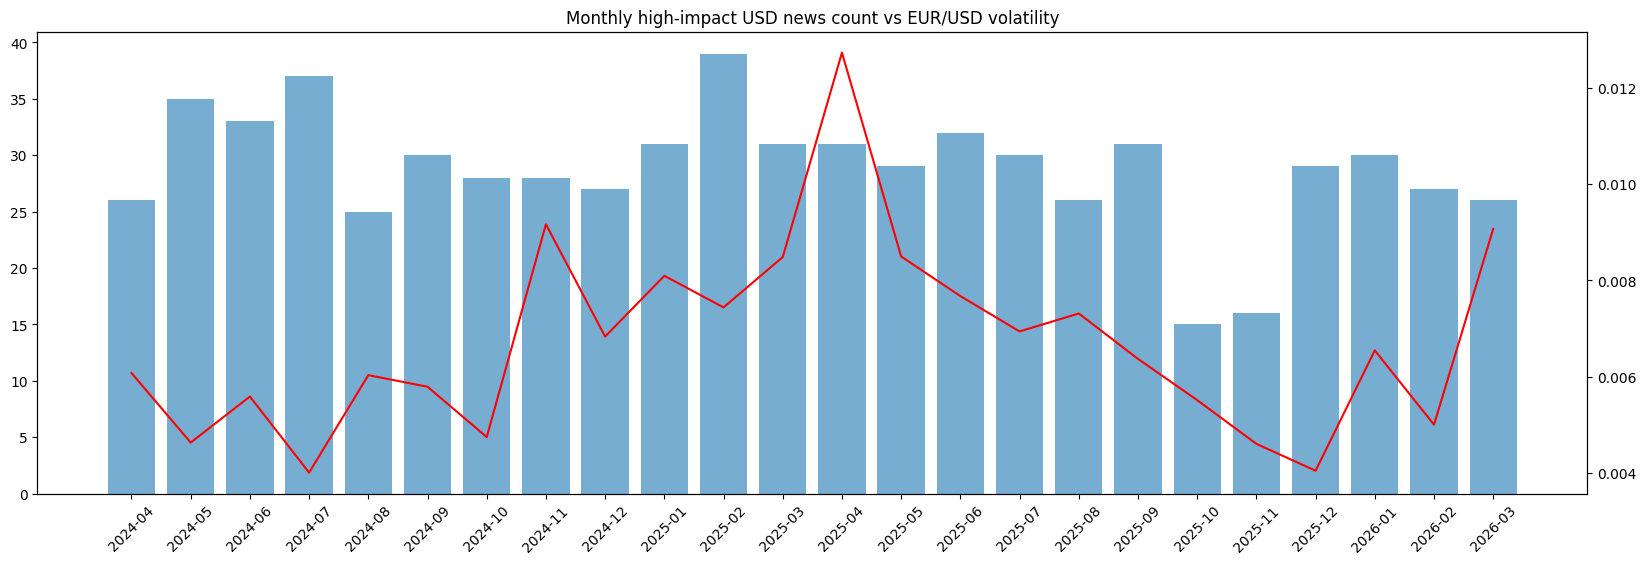

In [341]:
# taking only USD high-impact news
usd = df_events_final[
    (df_events_final["currency"] == "USD") &
    (df_events_final["impact_level"] == 3)
]
usd["month"] = usd["event_date"].dt.to_period("M")
monthly_news = usd.groupby("month").size().rename("news")

# EUR/USD volatility
usd = df_final[df_final["from_currency"] == "EUR"]
eur["month"] = eur["bar_date"].dt.to_period("M")
monthly_vol = eur.groupby("month")["volatility"].mean().rename("volatility")

df_plot = pd.concat([monthly_news, monthly_vol], axis=1).fillna({"news": 0})

fig, ax1 = plt.subplots(figsize=(20, 6))
ax1.bar(df_plot.index.astype(str), df_plot["news"], alpha=0.6)
ax1.tick_params(axis="x", rotation=45)
ax2 = ax1.twinx() # https://matplotlib.org/stable/api/_as_gen/matplotlib.axes.Axes.twinx.html
ax2.plot(df_plot.index.astype(str), df_plot["volatility"], color="red")

plt.title("Monthly high-impact USD news count vs EUR/USD volatility")
plt.show()

The volume of high-impact USD news events alone is a weak predictor of EUR/USD volatility. Volatility is episodic and regime-dependent - it spikes sharply around specific surprise events regardless of how many events are scheduled that month. This motivates a feature-based model that captures impact level, surprise direction, and event type rather than simply counting releases.

## Average abs currency return by event type

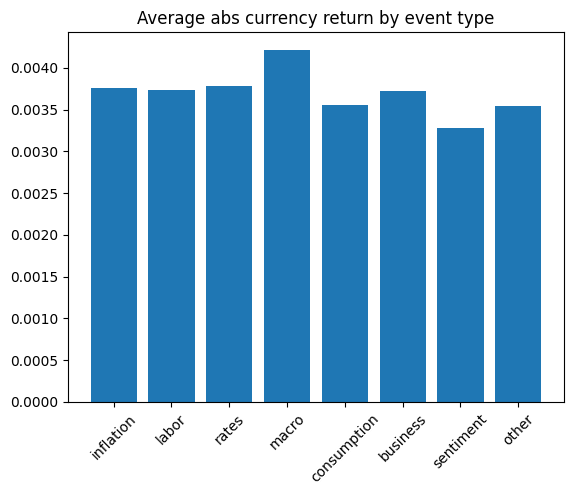

In [265]:
types = ["inflation","labor","rates","macro","consumption","business","sentiment","other"]
x = []
y = []

for t in types:
    data = df_final[df_final[t] > 0]["return"].abs()
    x.append(t)
    y.append(data.mean())

plt.bar(x, y)
plt.xticks(rotation=45)
plt.title("Average abs currency return by event type")
plt.show()

Macro events produce the highest average absolute return at approximately 0.0043, making them the most market-moving category. Rates, inflation, and labor follow closely behind, forming a second tier of high-impact events. The differences across categories are relatively small. This suggests that while macro events lead, no single category dramatically dominates over others in terms of average currency market impact.

## Volatility distribution by currency

/tmp/ipykernel_2131/889055161.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(groups, labels=currencies)


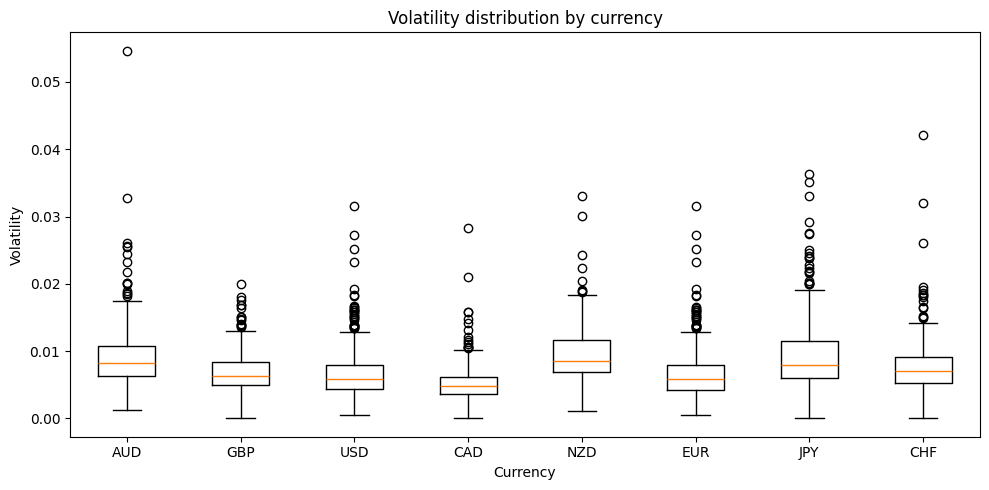

In [266]:
currencies = ["AUD", "GBP", "USD", "CAD", "NZD", "EUR", "JPY", "CHF"]

groups = []
for c in currencies:
    groups.append(df_final[df_final["currency"] == c]["volatility"].values)

fig, ax = plt.subplots(figsize=(10, 5))
ax.boxplot(groups, labels=currencies)
ax.set_ylabel("Volatility")
ax.set_xlabel("Currency")
plt.title("Volatility distribution by currency")
plt.tight_layout()
plt.show()

The chart shows that while day to day volatility is low and stable across all eight currencies, extreme spikes occur regularly in every one of them. AUD and NZD are the most volatile overall, CAD is the most stable. The universal presence of outliers across all currencies confirms that no currency is safe from sudden abnormal moves, which directly justifies the need for a systematic volatility prediction system.

## Currency by currency volatility based on high-impact news


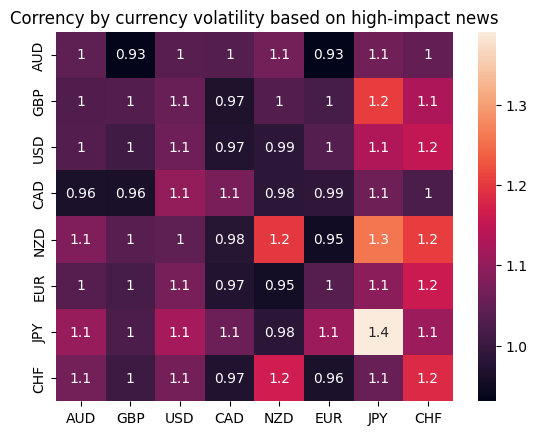

In [286]:
currencies = ["AUD", "GBP", "USD", "CAD", "NZD", "EUR", "JPY", "CHF"]

matrix = pd.DataFrame(index=currencies, columns=currencies)

for cur in currencies:
    for affected in currencies:
        dates = df_events_final[
            (df_events_final["currency"] == cur) &
            (df_events_final["impact_level"] == 3)
        ]["event_date"]

        data = df_final[
            (df_final["currency"] == affected) &
            (df_final["event_date"].isin(dates))
        ]["volatility"]

        base = df_final[df_final["currency"] == affected]["volatility"].mean()

        if len(data) > 0:
            delta = data.mean() / base
        else:
            delta = 1

        matrix.loc[affected, cur] = delta


sns.heatmap(matrix.astype(float), annot=True)
plt.title("Corrency by currency volatility based on high-impact news")
plt.show()

The heatmap shows that high-impact news events amplify volatility across most currency pairs, but the effect is uneven. GHF news events show the most elevated cross-currency effects. CAD news events consistently produce below-baseline or neutral readings across most currencies. Overall the chart confirms that scheduled news events carry a real and pair-specific volatility signal, directly supporting the case for a systematic prediction system.

## 30-day volatility for all currencies

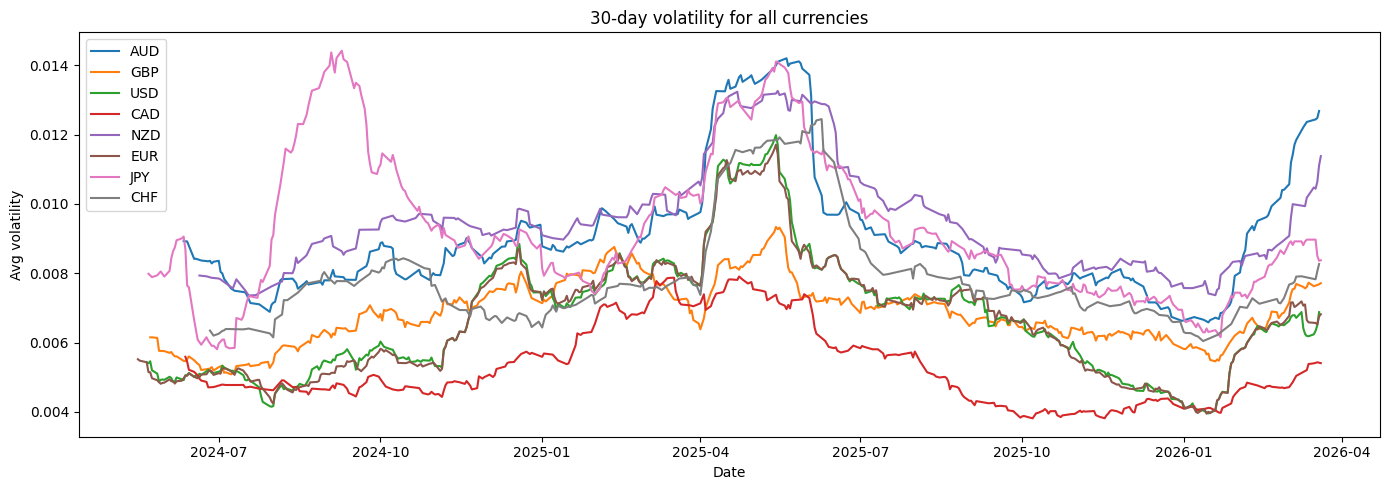

In [299]:
plt.figure(figsize=(14, 5))
for c in currencies:
    data = df_final[df_final["currency"] == c].sort_values("event_date")
    roll = data["volatility"].rolling(30).mean()
    plt.plot(data["event_date"], roll, label=c)
plt.title("30-day volatility for all currencies")
plt.xlabel("Date")
plt.ylabel("Avg volatility")
plt.legend()
plt.tight_layout()
plt.show()

Volatility across all currencies followed a clear cycle over the two-year period. JPY was a notable outlier with its own isolated spike in mid-2024. CAD remained the most stable currency throughout. The graph conludes that the same news event produces very different market reactions depending on the prevailing macro environment, which means the predictive model must account for these structural shifts.

## Usual effect rule accuracy per currency (>50% = rule holds, <50% = opposite effect)

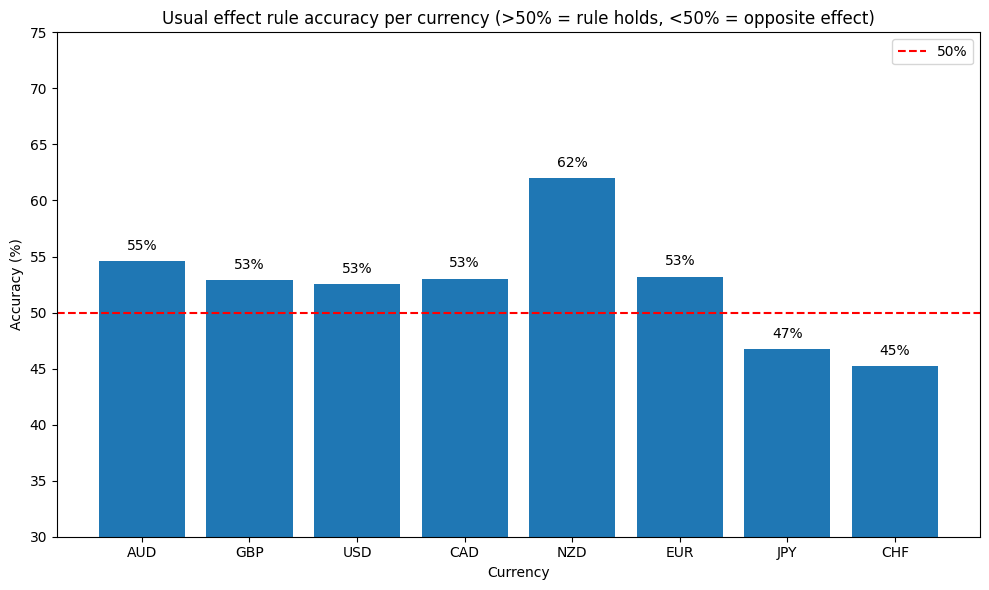

In [312]:
x = []
y = []

for c in currencies:
    data = df_final[
        (df_final["currency"] == c) &
        (df_final["signal_mean"] != 0)
    ]
    correct = (
        ((data["signal_mean"] > 0) & (data["return"] > 0)) |
        ((data["signal_mean"] < 0) & (data["return"] < 0))
    )

    accuracy = correct.mean() * 100
    x.append(c)
    y.append(accuracy)

plt.figure(figsize=(10, 6))
plt.bar(x, y)
plt.axhline(50, color="red", linestyle="--", label="50%")

for i in range(len(y)):
    plt.text(x[i], y[i] + 1, f"{y[i]:.0f}%", ha="center")

plt.ylim(30, 75)
plt.xlabel("Currency")
plt.ylabel("Accuracy (%)")
plt.title("Usual effect rule accuracy per currency (>50% = rule holds, <50% = opposite effect)")
plt.legend()
plt.tight_layout()
plt.show()

The usual effect rule holds for most currencies but only marginally. AUD, GBP, USD, CAD, and EUR all sit just above 50% at 53–55%, meaning the rule is correct slightly more often than not. NZD is the clear outlier at 62%, where the rule is meaningfully predictive.

## Daily event count vs currency volatility for all currencies

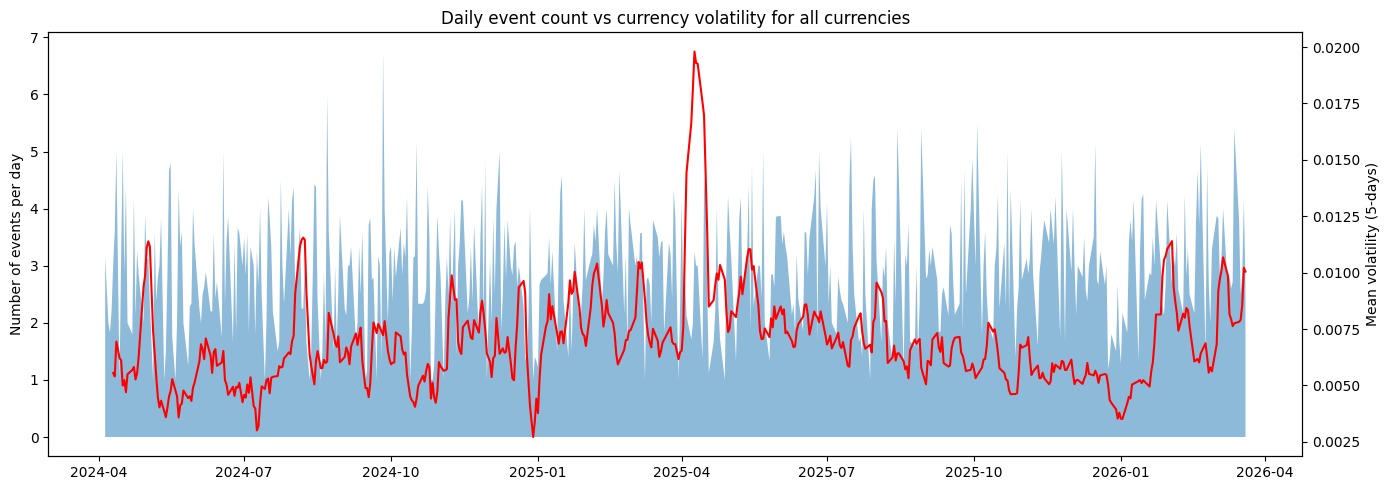

In [330]:
ts = df_final.groupby("event_date")[["event_count", "volatility"]].mean()

fig, ax1 = plt.subplots(figsize=(14,5))

ax1.fill_between(ts.index, ts["event_count"], alpha=0.5) #https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.fill_between.html
ax1.set_ylabel("Number of events per day")
ax1.set_title("Daily event count vs currency volatility for all currencies")

ax2 = ax1.twinx()
ax2.plot(ts.index, ts["volatility"].rolling(5).mean(), color='red')
ax2.set_ylabel("Mean volatility (5-days)")

plt.tight_layout()
plt.show()

The event count alone is a weak predictor of volatility - what matters is not how many events occur but which events and in what macro regime.

## Return distribution by signal direction

/tmp/ipykernel_2131/1278974808.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["direction"] = df["signal_mean"] > 0


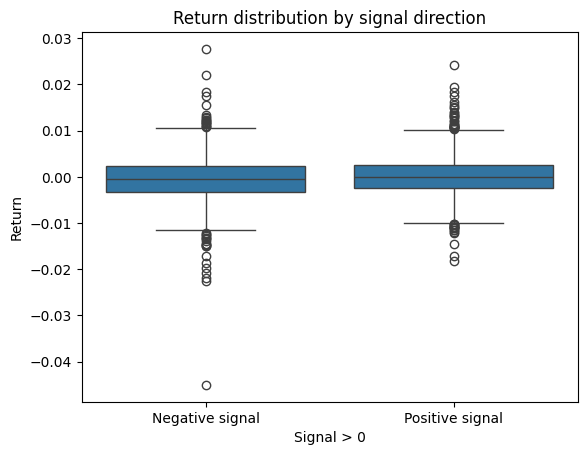

In [342]:
df = df_final[df_final["signal_mean"] != 0]
df["direction"] = df["signal_mean"] > 0

sns.boxplot(x="direction", y="return", data=df)

plt.title("Return distribution by signal direction")
plt.xlabel("Signal > 0")
plt.ylabel("Return")

plt.xticks([0,1], ["Negative signal", "Positive signal"])

plt.show()

Both distributions are centred almost exactly at zero with nearly identical box sizes, meaning the signal direction does not reliably predict the direction of returns. The negative signal group has noticeably heavier tails on both sides, compared to the positive signal group which is more contained. This suggests that negative signals are associated with larger magnitude moves when extremes do occur.